# Overview of H37Rv High-Homology and repetitive Regions  

# Import Statements (libraries + Functions)

In [3]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [4]:
import ast

In [5]:
# Define matplotlib plot style from config file
#plt.style.use('../mgm.v1.mplstyle')

In [6]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [7]:
from Bio import SeqIO


In [8]:
import json

In [9]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [10]:
import subprocess

In [11]:
from pycirclize import Circos


In [12]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

#### Pandas Viewing Settings

In [13]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [14]:
from gcutils.general import label_DF_ByOvrLapGenes


# Define Custom Functions

In [15]:

def mergeRegionDFs_and_sum_lengths(list_of_dfs, core_cols=["chrom", "start", "end"]):
    """
    Merge genomic intervals from multiple DataFrames and calculate total merged length.

    Parameters
    ----------
    list_of_dfs : list of pd.DataFrame
        Each DataFrame must contain columns ["chrom", "start", "end"].
    core_cols : list of str, optional
        Columns to subset before merging, by default ["chrom", "start", "end"].

    Returns
    -------
    total_length : int
        Sum of merged region lengths.
    merged_df : pd.DataFrame
        Merged DataFrame with added "Length" column.
    """
    # Subset each DataFrame to core columns
    dfs_core = [df[core_cols] for df in list_of_dfs]

    # Concatenate all DataFrames
    cat_df = pd.concat(dfs_core, axis=0)

    # Merge overlapping/adjacent regions
    merged_df = bf.merge(cat_df, min_dist=None)

    # Compute length of each region
    merged_df["Length"] = merged_df["end"] - merged_df["start"]

    # Sum total length
    total_length = merged_df["Length"].sum()

    return total_length, merged_df


In [16]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from upsetplot import UpSet, from_memberships


In [17]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from upsetplot import UpSet, from_memberships


def compute_union_sizes(region_dict: dict[str, pd.DataFrame]):
    """
    Compute union lengths for all non-empty subsets of the region sets.
    For singletons, use df['Length'].sum() directly.
    For multi-set subsets, call your mergeRegionDFs_and_sum_lengths.
    """
    names = list(region_dict.keys())
    union_sizes = {}

    # single sets: just sum Length
    for name in names:
        union_sizes[frozenset([name])] = int(region_dict[name]["Length"].sum())

    # multi-sets: use your union function
    for k in range(2, len(names) + 1):
        for combo in itertools.combinations(names, k):
            dfs = [region_dict[n] for n in combo]
            total_len, _ = mergeRegionDFs_and_sum_lengths(dfs)
            union_sizes[frozenset(combo)] = int(total_len)

    return union_sizes

def mobius_exclusive_from_unions(union_sizes: dict[frozenset, int]):
    """
    Convert union sizes for all non-empty subsets into EXCLUSIVE sizes
    (exactly-in-that-combination) via inclusion–exclusion.
    """
    # order keys by subset size, then lexicographically for determinism
    keys_sorted = sorted(union_sizes.keys(), key=lambda s: (len(s), tuple(sorted(s))))
    exclusive = {}
    for key in keys_sorted:  # increasing size
        k = len(key)
        excl = union_sizes[key]
        # subtract exclusive sizes of all proper non-empty sub-subsets
        for j in range(1, k):
            for sub in itertools.combinations(key, j):
                excl -= exclusive[frozenset(sub)]
        exclusive[key] = max(int(excl), 0)  # guard tiny negatives
    return exclusive

def summarize_overlaps(region_dict: dict[str, pd.DataFrame]):
    union_sizes = compute_union_sizes(region_dict)
    exclusive_sizes = mobius_exclusive_from_unions(union_sizes)

    # tidy table
    rows = []
    for key in sorted(union_sizes, key=lambda s: (len(s), tuple(sorted(s)))):
        rows.append({
            "subset": tuple(sorted(key)),
            "k": len(key),
            "union_bp": union_sizes[key],
            "exclusive_bp": exclusive_sizes[key],
        })
    table = pd.DataFrame(rows)
    return {"union_bp_by_subset": union_sizes,
            "exclusive_bp_by_subset": exclusive_sizes,
            "table": table}

# ---- Plotting helpers ----

def plot_three_set_venn(exclusive_sizes: dict[frozenset, int], triplet=("PR","LRR","LCR")):
    A, B, C = triplet
    areas = {
        '100': exclusive_sizes.get(frozenset([A]), 0),
        '010': exclusive_sizes.get(frozenset([B]), 0),
        '001': exclusive_sizes.get(frozenset([C]), 0),
        '110': exclusive_sizes.get(frozenset([A, B]), 0),
        '101': exclusive_sizes.get(frozenset([A, C]), 0),
        '011': exclusive_sizes.get(frozenset([B, C]), 0),
        '111': exclusive_sizes.get(frozenset([A, B, C]), 0),
    }
    plt.figure(figsize=(6, 5))
    venn3(subsets=areas, set_labels=triplet)
    plt.title(f"Exclusive overlaps (bp): {triplet}")
    plt.show()

def plot_upset(exclusive_sizes: dict[frozenset, int], set_names=("PR","LRR","LCR","LowPmap"), i_sort_by = 'cardinality'):
    memberships, values = [], []
    for combo, bp in exclusive_sizes.items():
        memberships.append(tuple(sorted(combo)))
        values.append(bp)
        
    s = from_memberships(memberships, data=values)
    i_fig = plt.figure(figsize=(20, 5))
    
    upset = UpSet(s,
                  show_counts=True,
                  totals_plot_elements = 0,
                  sort_by = i_sort_by)

    upset.plot(fig=i_fig)

    # if hasattr(upset, "cat_totals") and upset.cat_totals is not None:
    #     upset.cat_totals.remove()

    plt.suptitle("UpSet: exclusive overlap sizes (bp)")

    return i_fig



def plot_upset_singletons_and_all(exclusive_sizes: dict[frozenset, int],
                                  set_names=("PR","LRR","LCR","LowPmap"), 
                                  i_sort_by = 'cardinality'):
    memberships, values = [], []
    for combo, bp in exclusive_sizes.items():
        if (len(combo) == 1) or (len(combo) == 4):
            memberships.append(tuple(sorted(combo)))
            values.append(bp)
        
    s = from_memberships(memberships, data=values)
    i_fig = plt.figure(figsize=(20, 5))
    
    upset = UpSet(s,
                  show_counts=True,
                  totals_plot_elements = 0,
                  sort_by = i_sort_by)

    upset.plot(fig=i_fig)

    # if hasattr(upset, "cat_totals") and upset.cat_totals is not None:
    #     upset.cat_totals.remove()

    plt.suptitle("UpSet: exclusive overlap sizes (bp)")

    return i_fig

# Import/parse processed H37rv genome annotations

In [18]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [19]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Define paths to H37Rv genome masking schemes

In [20]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [21]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [22]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [23]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


## Define a table of all transposase genes within H37Rv (`Mycobrowser`)

In [24]:
Transposase_Genes_DF = H37Rv_GenomeAnno_Genes_DF[ (H37Rv_GenomeAnno_Genes_DF["Product"].str.contains("transposase")) | (H37Rv_GenomeAnno_Genes_DF["Product"].str.contains("Transposase"))  ]    
Transposase_Genes_DF.shape

(88, 12)

In [25]:
IS6110_Labled_Genes_DF = Transposase_Genes_DF[ Transposase_Genes_DF["Product"].str.contains("IS6110") ]
IS6110_Labled_Genes_DF.shape

(18, 12)

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [26]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [27]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF["chrom"] = HmMapRegs_ParaRegs_k19w19_DF["Chr"]
HmMapRegs_ParaRegs_k19w19_DF["start"] = HmMapRegs_ParaRegs_k19w19_DF["Start"]
HmMapRegs_ParaRegs_k19w19_DF["end"] = HmMapRegs_ParaRegs_k19w19_DF["End"]

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 18)

In [28]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF["chrom"] = HmMapRegs_LocalRepeats_k19w19_DF["Chr"]
HmMapRegs_LocalRepeats_k19w19_DF["start"] = HmMapRegs_LocalRepeats_k19w19_DF["Start"]
HmMapRegs_LocalRepeats_k19w19_DF["end"]   = HmMapRegs_LocalRepeats_k19w19_DF["End"]

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 16)

In [29]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 18)

In [30]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,chrom,start,end
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,NC_000962.3,80184,80523
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,NC_000962.3,80623,82664


In [31]:
HmMapRegs_LocalRepeats_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,chrom,start,end
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000,NC_000962.3,333811,335879
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001,NC_000962.3,366430,375121


#### Peak at head of each HmMap Regions DFs

In [32]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,chrom,start,end
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,NC_000962.3,80184,80523
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,NC_000962.3,80623,82664
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,NC_000962.3,103705,105130
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4,NC_000962.3,149571,149808
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5,NC_000962.3,177203,177447


In [33]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,chrom,start,end
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000,NC_000962.3,333811,335879
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001,NC_000962.3,366430,375121
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002,NC_000962.3,424011,432951
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003,NC_000962.3,566288,580814
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004,NC_000962.3,631298,631436


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [34]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [35]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [36]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [37]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 38)


In [38]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 38)


In [39]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 38)


### Parse in HomologyMap Alignment Variants DFs

In [40]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [41]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(52699, 6)

In [42]:
Mtb_HM_Var_DF.shape

(79508, 14)

In [43]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 14)

# Parse `LowComplexity` and `Low-Mappability` Regions of H37Rv

In [44]:
RepoRef_Dir = "../../References"
Rv_longdust_LCB_OutDir = f"{RepoRef_Dir}/H37Rv_Longdust_LowComplexityRegions"
Rv_LowPupMap_OutDir = f"{RepoRef_Dir}/H37Rv_MappabilityAnalysis_K50E4"

Rv_LowPupmap_K50E4_TSV = f"{Rv_LowPupMap_OutDir}/H37Rv.LowPileupMap.Below1.K50_E4.tsv"
Rv_LowComplexityRegions_TSV = f"{Rv_longdust_LCB_OutDir}/H37Rv.longdust.LCR.relaxedshorter.tsv"


#### Create DF of Low Complexity Regions - defiend by `longdust` (params:`-k6 -w1000 -t .5`)

In [45]:
Rv_LCRs_DF = pd.read_csv(Rv_LowComplexityRegions_TSV, sep ="\t")
Rv_LCRs_DF.shape

(231, 5)

In [46]:
Rv_LCRs_DF.head()

,chrom,start,end,Length,Overlap_Genes
0,NC_000962.3,7158,7172,14,gyrB
1,NC_000962.3,17896,17904,8,pknA
2,NC_000962.3,18053,18067,14,pknA
3,NC_000962.3,50046,50057,11,ino1
4,NC_000962.3,55533,55555,22,ponA1


#### Create DF of Low Pileup Mappability Regions - defined by `pupmapper`/`genmap` (K=50bp,E=4 mismatches)

In [47]:
Rv_LowPmap_DF = pd.read_csv(Rv_LowPupmap_K50E4_TSV, sep ="\t")
Rv_LowPmap_DF.shape

(1092, 5)

In [48]:
Rv_LowPmap_DF.head()

,chrom,start,end,Length,Overlap_Genes
0,NC_000962.3,23172,23237,65,pstP
1,NC_000962.3,79498,79573,75,Rv0071
2,NC_000962.3,80180,80379,199,Rv0071
3,NC_000962.3,80458,80517,59,_
4,NC_000962.3,82165,82237,72,Rv0073


# Explicitly define the specific 4 categories of "Homologous and repetitive genome content"

a) Paralogous Regions, `PR`: Paralogous regions were defined as non-overlapping homologous segments between distinct genomic loci.

b) Local Repeat Region, `LRR`: Local repeat regions were defined as overlapping self-alignments, reflecting tandem or proximal repeats in which consecutive elements share homology.

c) Low Complexity Regions `LCR`: Low-complexity regions were defined as sequences enriched for short tandem motifs, including imperfect or approximate repeats.

d) Low pileup mappability regions, `LowPmap` :Low-mappability regions were defined as intervals with non-unique k-mer content, using a k-mer size of 50 bp.


### a) Paralogous Regions, `PR`

In [49]:
HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 18)

In [50]:
HmMapRegs_ParaRegs_k19w19_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,chrom,start,end
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,NC_000962.3,80184,80523


In [51]:
HmMapRegs_ParaRegs_k19w19_DF["Length"].sum()

256568

### b) Local Repeat Region, `LRR`

In [52]:
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 16)

In [53]:
HmMapRegs_LocalRepeats_k19w19_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,chrom,start,end
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000,NC_000962.3,333811,335879


In [54]:
HmMapRegs_LocalRepeats_k19w19_DF["Length"].sum()

149809

### c) Low Complexity Regions `LCR`

In [55]:
Rv_LCRs_DF.shape

(231, 5)

In [56]:
Rv_LCRs_DF.head(1)

,chrom,start,end,Length,Overlap_Genes
0,NC_000962.3,7158,7172,14,gyrB


In [57]:
Rv_LCRs_DF["Length"].sum()

127160

### d) Low pileup mappability regions, `LowPmap`

In [58]:
Rv_LowPmap_DF.shape

(1092, 5)

In [59]:
Rv_LowPmap_DF.head(1)

,chrom,start,end,Length,Overlap_Genes
0,NC_000962.3,23172,23237,65,pstP


In [60]:
Rv_LowPmap_DF["Length"].sum()

189147

# Begin analysis and comparison of distinct regions

In [61]:
Rv_LowPmap_DF["Length"].sum()

189147

In [62]:
Rv_LowPmap_DF["Length"].sum()

189147

### Look stats for each region individually

In [63]:
HmAndRepRegions_Dict = {"Paralogous_Regions"  : HmMapRegs_ParaRegs_k19w19_DF,
                        "LocalRepeat_Regions" : HmMapRegs_LocalRepeats_k19w19_DF,
                        "LowComp_Regions"     : Rv_LCRs_DF,
                        "LowPmap_Regions"     : Rv_LowPmap_DF}


for name, i_Reg_DF in HmAndRepRegions_Dict.items():

    print(name, i_Reg_DF["Length"].sum(), "bp")
    print(name, i_Reg_DF.shape[0], " total regions")
    print("---------\n")


Paralogous_Regions 256568 bp
Paralogous_Regions 200  total regions
---------

LocalRepeat_Regions 149809 bp
LocalRepeat_Regions 50  total regions
---------

LowComp_Regions 127160 bp
LowComp_Regions 231  total regions
---------

LowPmap_Regions 189147 bp
LowPmap_Regions 1092  total regions
---------



##### How many pairs of intra-genome alignments detected in homology map (`Non-overlapping`, `paralogous regions`)

In [64]:
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [65]:
HmMap_Aln_k19w19_NoOverlap_DF["PerfectRepeat"].value_counts()

PerfectRepeat
False    385
True     255
Name: count, dtype: int64

In [66]:
HmMap_Aln_k19w19_NoOverlap_DF.head()

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


In [67]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == True").shape

(255, 38)

In [68]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == True & Query_NOvrlap_Transposase > 1").shape

(221, 38)

In [69]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == True & Target_NOvrlap_Transposase > 1").shape

(221, 38)

In [70]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False & Query_NOvrlap_Transposase > 1").shape

(22, 38)

In [71]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False & Target_NOvrlap_Transposase > 1").shape

(22, 38)

In [72]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False").shape

(385, 38)

In [73]:
HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False & Query_NOvrlap_Transposase > 1").shape

(22, 38)

In [74]:
#HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == True & Query_NOvrlap_IS6110_Label > 1").shape

In [75]:
#HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == True & Target_NOvrlap_IS6110_Label > 1").shape

In [76]:
#HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False & Query_NOvrlap_IS6110_Label > 1").shape

In [77]:
#HmMap_Aln_k19w19_NoOverlap_DF.query("PerfectRepeat == False & Target_NOvrlap_IS6110_Label > 1").shape

In [78]:
HmAndRepRegions_Dict["Paralogous_Regions"].head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,chrom,start,end
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,NC_000962.3,80184,80523
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,NC_000962.3,80623,82664
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,NC_000962.3,103705,105130
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4,NC_000962.3,149571,149808
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5,NC_000962.3,177203,177447


In [79]:
HmAndRepRegions_Dict["Paralogous_Regions"].query("num_HmAln_PR_BelowSeqID100 == 0").shape

(21, 18)

In [80]:
HmAndRepRegions_Dict["Paralogous_Regions"].query("num_HmAln_PR_BelowSeqID100 == 0").shape

(21, 18)

In [81]:
HmAndRepRegions_Dict["Paralogous_Regions"].query("NOvrlap_Transposase >= 1").shape

(37, 18)

In [82]:
HmAndRepRegions_Dict["Paralogous_Regions"].query("NOvrlap_Transposase == 0").shape

(163, 18)

### Analysis overlap of all combinations of regions

In [83]:
# ---- Example usage with your data ----
region_sets = {
    "PR":      HmAndRepRegions_Dict["Paralogous_Regions"],   # has "chrom,start,end,Length"
    "LRR":     HmAndRepRegions_Dict["LocalRepeat_Regions"],
    "LCR":     HmAndRepRegions_Dict["LowComp_Regions"],
    "LowPmap": HmAndRepRegions_Dict["LowPmap_Regions"],
}

overlap_summary = summarize_overlaps(region_sets)
overlap_summary["table"][["subset", "union_bp"]]


,subset,union_bp
0,"(LCR,)",127160
1,"(LRR,)",149809
2,"(LowPmap,)",189147
3,"(PR,)",256568
4,"(LCR, LRR)",225262
5,"(LCR, LowPmap)",278110
6,"(LCR, PR)",337556
7,"(LRR, LowPmap)",299505
8,"(LRR, PR)",363897
9,"(LowPmap, PR)",299890


In [84]:
127160 + 149809

276969

In [85]:
overlap_summary.keys()

dict_keys(['union_bp_by_subset', 'exclusive_bp_by_subset', 'table'])

In [86]:
overlap_summary["union_bp_by_subset"]

{frozenset({'PR'}): 256568,
 frozenset({'LRR'}): 149809,
 frozenset({'LCR'}): 127160,
 frozenset({'LowPmap'}): 189147,
 frozenset({'LRR', 'PR'}): 363897,
 frozenset({'LCR', 'PR'}): 337556,
 frozenset({'LowPmap', 'PR'}): 299890,
 frozenset({'LCR', 'LRR'}): 225262,
 frozenset({'LRR', 'LowPmap'}): 299505,
 frozenset({'LCR', 'LowPmap'}): 278110,
 frozenset({'LCR', 'LRR', 'PR'}): 422673,
 frozenset({'LRR', 'LowPmap', 'PR'}): 392939,
 frozenset({'LCR', 'LowPmap', 'PR'}): 368647,
 frozenset({'LCR', 'LRR', 'LowPmap'}): 362480,
 frozenset({'LCR', 'LRR', 'LowPmap', 'PR'}): 447067}

## Visualize overlap of all combinations of regions

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

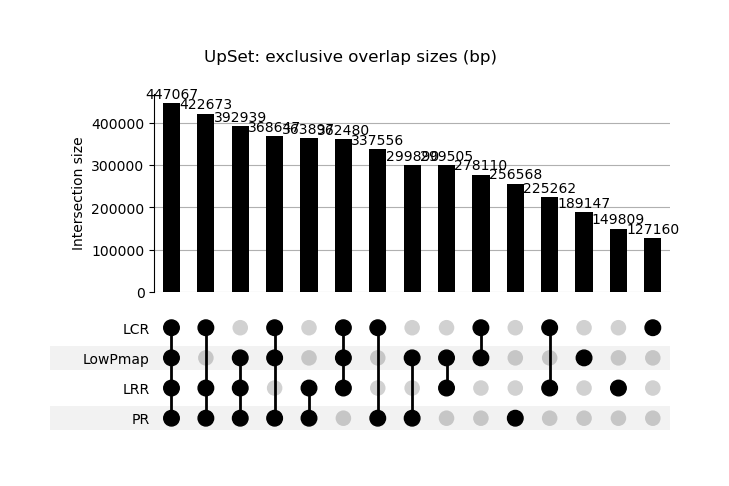

In [87]:
AllReg_Upset_Fig = plot_upset(overlap_summary["union_bp_by_subset"])


/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

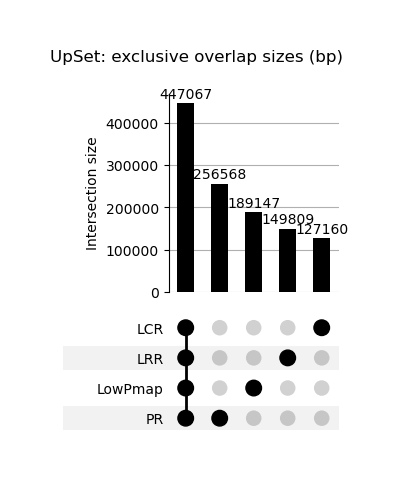

In [88]:
AllReg_WiSingles_Upset_Fig = plot_upset_singletons_and_all(overlap_summary["union_bp_by_subset"])


In [89]:
overlap_summary["union_bp_by_subset"]

{frozenset({'PR'}): 256568,
 frozenset({'LRR'}): 149809,
 frozenset({'LCR'}): 127160,
 frozenset({'LowPmap'}): 189147,
 frozenset({'LRR', 'PR'}): 363897,
 frozenset({'LCR', 'PR'}): 337556,
 frozenset({'LowPmap', 'PR'}): 299890,
 frozenset({'LCR', 'LRR'}): 225262,
 frozenset({'LRR', 'LowPmap'}): 299505,
 frozenset({'LCR', 'LowPmap'}): 278110,
 frozenset({'LCR', 'LRR', 'PR'}): 422673,
 frozenset({'LRR', 'LowPmap', 'PR'}): 392939,
 frozenset({'LCR', 'LowPmap', 'PR'}): 368647,
 frozenset({'LCR', 'LRR', 'LowPmap'}): 362480,
 frozenset({'LCR', 'LRR', 'LowPmap', 'PR'}): 447067}

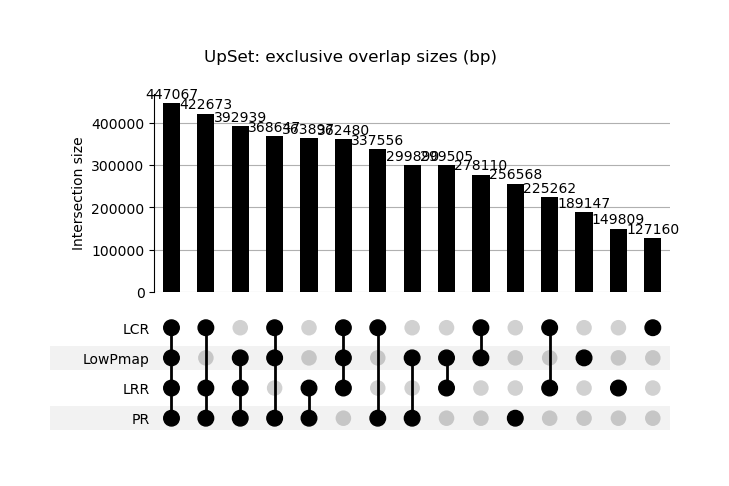

In [90]:
AllReg_Upset_Fig

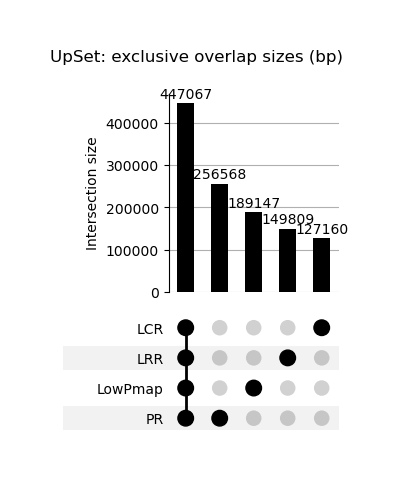

In [91]:
AllReg_WiSingles_Upset_Fig

# Part 2: Plot location of all Repetitive and High-homology regions in H37Rv

In [92]:
# ---- helper to add a region track ----
def add_interval_track(sector, df, r_inner, r_outer, color, label=None, alpha=0.9, edgecolor=None):
    tr = sector.add_track((r_inner, r_outer))
    tr.axis(fc="white", ec="none")  # clean band under features
    # draw each interval as a rectangle on the ring
    # (pycirclize Track.rect takes x-positions in genomic coords) 
    for s, e in df[["start", "end"]].itertuples(index=False):
        tr.rect(float(s), float(e), fc=color, ec=edgecolor, alpha=alpha)
    # if label:
    #     # annotate track label at start of chromosome
    #     tr.annotate(0, label, label_size=10, line_kws=dict(color="black", lw=0.5))
    return tr
    

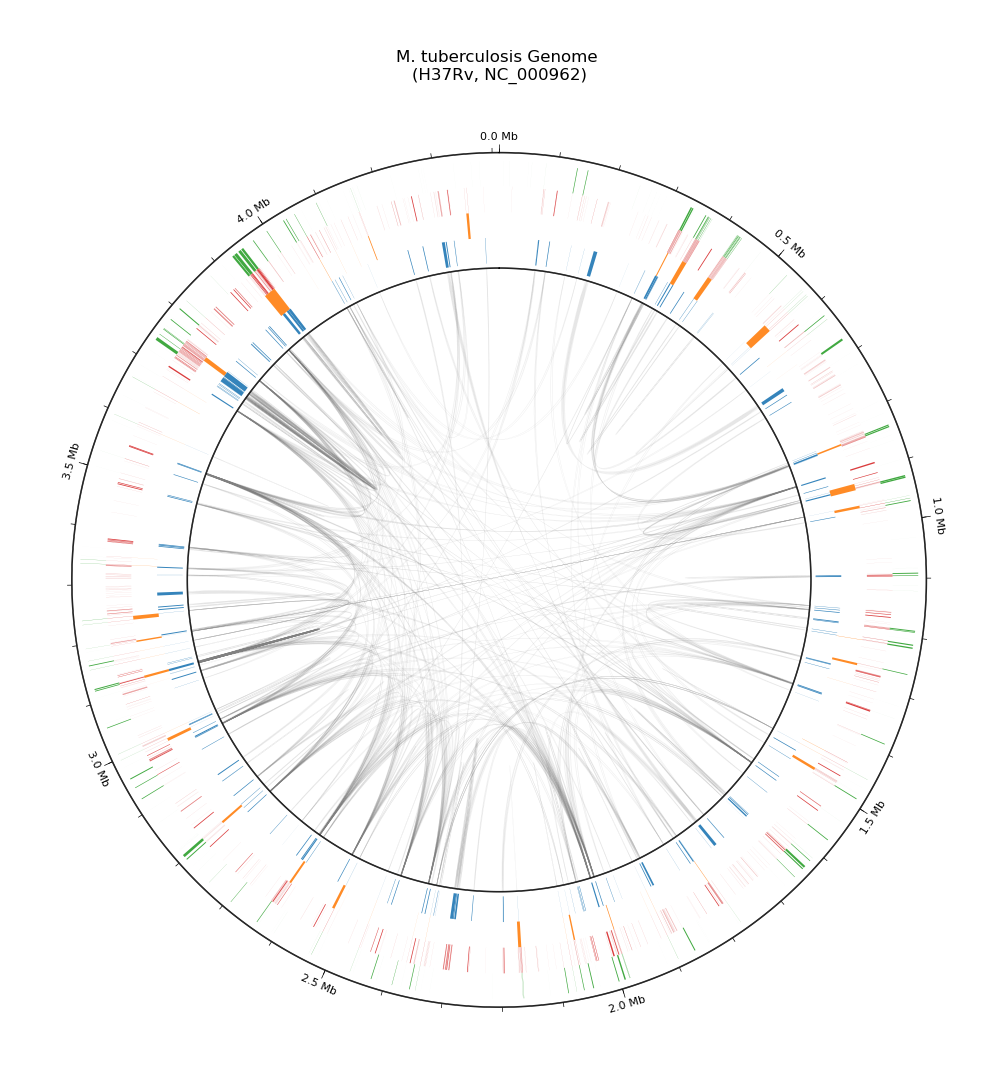

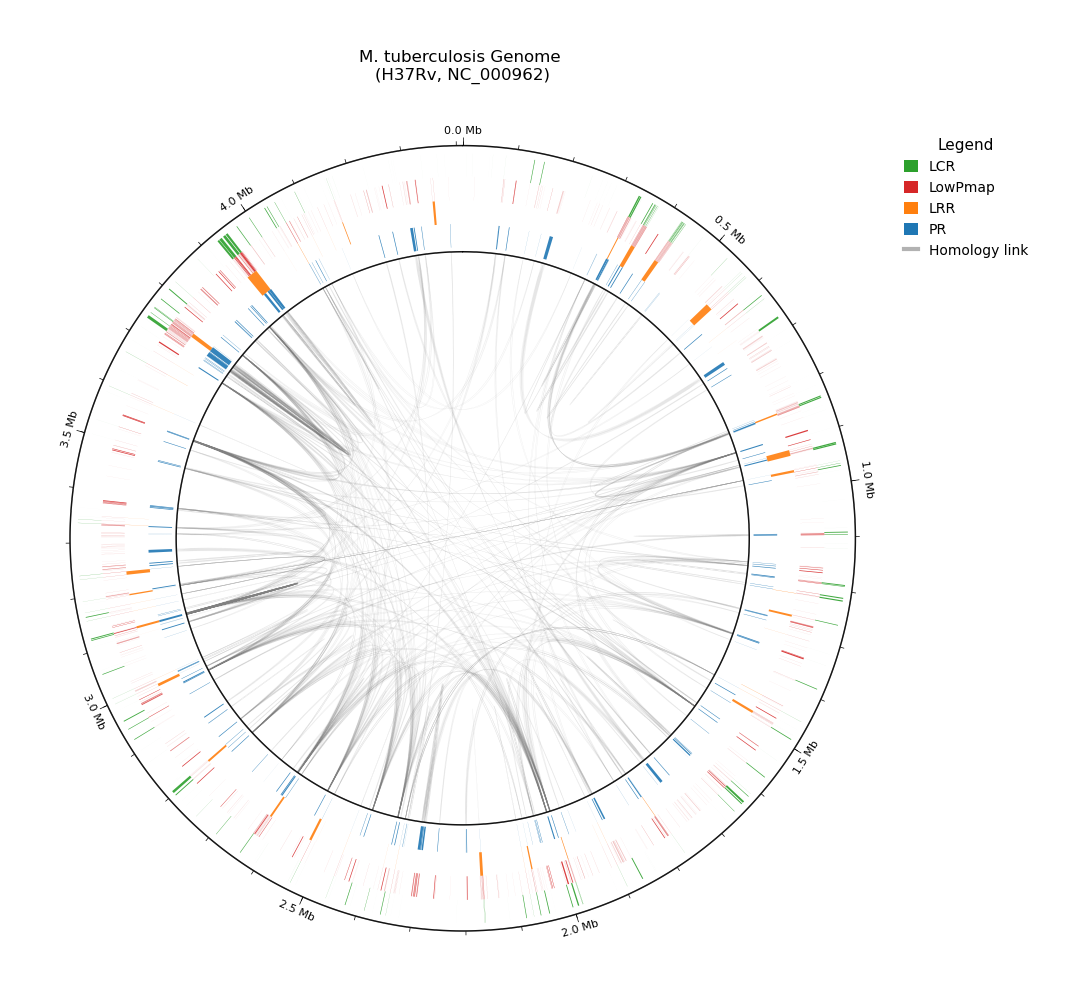

In [93]:

circos = Circos(sectors={"NC_000962.3": 4411532})

#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=120)

sector = circos.get_sector("NC_000962.3")

#### Outer track ####
# Plot outer track with xticks
major_ticks_interval = 500000
minor_ticks_interval = 100000
outer_track = sector.add_track((99.8, 100))
outer_track.axis(fc="lightgrey")
outer_track.xticks_by_interval(
    major_ticks_interval, label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb"
)
outer_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

#####################

##########################################



# ---- pick colors & add one track per region set ----
PR_df   = HmAndRepRegions_Dict["Paralogous_Regions"]
LRR_df  = HmAndRepRegions_Dict["LocalRepeat_Regions"]
LCR_df  = HmAndRepRegions_Dict["LowComp_Regions"]
LPm_df  = HmAndRepRegions_Dict["LowPmap_Regions"]

# radial layout (outer → inner). Adjust as you like.
add_interval_track(sector, LCR_df, 92, 98,  color="#2ca02c", label="LCR")
add_interval_track(sector, LPm_df, 86, 92,  color="#d62728", label="LowPmap")
add_interval_track(sector, LRR_df, 80, 86,  color="#ff7f0e", label="LRR")
add_interval_track(sector, PR_df,  74, 80,  color="#1f77b4", label="PR")

inner_track = sector.add_track((72.8, 73))
inner_track.axis(fc="lightgrey")

#### Draw links of homology map alignments ####
in_HmMapAln_DF = HmMap_Aln_k19w19_NoOverlap_DF

for i, row in in_HmMapAln_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 500, row["Query_End"] + 500)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 500, row["Target_End"] + 500)
    circos.link(i_region1, i_region2,
                color="grey", direction = 1, alpha = 0.1,)
    
# ---- render ----
fig = circos.plotfig(figsize=(10, 10))


from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ---- render ----
HmRep_Circos_fig = circos.plotfig(figsize=(10, 10))

ax = HmRep_Circos_fig.axes[0]

# Build legend handles
handles = [
    Patch(facecolor="#2ca02c", edgecolor="none", label="LCR"),
    Patch(facecolor="#d62728", edgecolor="none", label="LowPmap"),
    Patch(facecolor="#ff7f0e", edgecolor="none", label="LRR"),
    Patch(facecolor="#1f77b4", edgecolor="none", label="PR"),
    Line2D([0], [0], color="grey", lw=3, alpha=0.6, label="Homology link"),
]

# Place legend on the first (main) axis
ax.legend(
    handles=handles,
    loc="upper right",            # inside the plot, upper-right corner
    bbox_to_anchor=(1.2, 1),
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="0.8",
    title="Legend",
    fontsize=10,
    title_fontsize=11,
)

plt.show()

### Look at final fig object

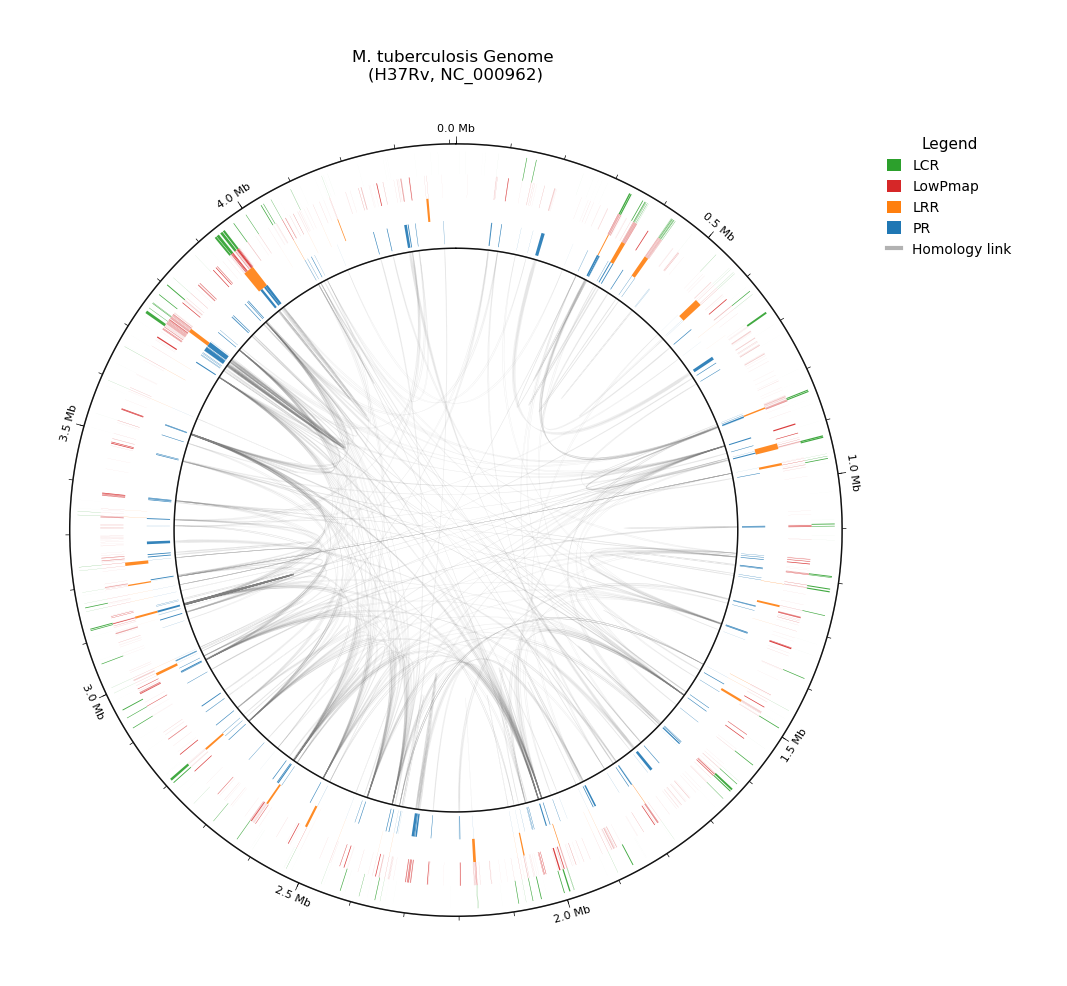

In [94]:
HmRep_Circos_fig

## Save circos plot of HighHomologyAndRepetitiveRegions for H37Rv

In [120]:
!mkdir ./H37Rv_NonUnqSeq_Viz/

In [121]:
# save in current directory
HmRep_Circos_fig.savefig("./H37Rv_NonUnqSeq_Viz/H37Rv.HighHomologyAndRepetitiveRegions.circos_plot.png", dpi=300, bbox_inches="tight")
HmRep_Circos_fig.savefig("./H37Rv_NonUnqSeq_Viz/H37Rv.HighHomologyAndRepetitiveRegions.circos_plot.svg", bbox_inches="tight")


# Create a BED DF that represents the UNION of all non-unique sequence regions

In [96]:
PR_df   = HmAndRepRegions_Dict["Paralogous_Regions"]
LRR_df  = HmAndRepRegions_Dict["LocalRepeat_Regions"]
LCR_df  = HmAndRepRegions_Dict["LowComp_Regions"]
LPm_df  = HmAndRepRegions_Dict["LowPmap_Regions"]


In [97]:
i_UnionLen, Rv_NonUnqSeq_Union_Try2_DF = mergeRegionDFs_and_sum_lengths([ PR_df,
                                                                         LRR_df,
                                                                         LCR_df,
                                                                         LPm_df ])

Rv_NonUnqSeq_Union_DF = label_DF_ByOvrLapGenes(
                       Rv_NonUnqSeq_Union_Try2_DF,
                       H37Rv_GenomeAnno_Genes_DF,
                       i_cols1 = ("chrom", "start", "end") )

Rv_NonUnqSeq_Union_DF.shape

(664, 6)

In [98]:
Rv_NonUnqSeq_Union_DF["Length"].sum()

447067

In [99]:
Rv_NonUnqSeq_Union_DF.head(5)

,chrom,start,end,n_intervals,Length,Overlap_Genes
0,NC_000962.3,7158,7172,1,14,gyrB
1,NC_000962.3,17896,17904,1,8,pknA
2,NC_000962.3,18053,18067,1,14,pknA
3,NC_000962.3,23172,23237,1,65,pstP
4,NC_000962.3,50046,50057,1,11,ino1


# Output tables of H37Rv Non-unique Seq content

In [109]:
Data_RepoDir = "../../Data"

Rv_NonUnqRegions_OutDir = f"{Data_RepoDir}/H37Rv.NonUniqueSeqRegions.V1"

!mkdir $Rv_NonUnqRegions_OutDir

i_Rv_ParalogousRegions_TSV = f"{Rv_NonUnqRegions_OutDir}/H37Rv.Minimap2.HomologyMap.ParalogousRegions.tsv.gz"
i_Rv_LocalRepeatRegions_TSV      = f"{Rv_NonUnqRegions_OutDir}/H37Rv.Minimap2.HomologyMap.LocalRepeatRegions.tsv.gz"

i_Rv_LowComplexityRegions_TSV = f"{Rv_NonUnqRegions_OutDir}/H37Rv.longdust.LCR.relaxedshorter.tsv.gz"
i_Rv_LowPupmap_K50E4_TSV      = f"{Rv_NonUnqRegions_OutDir}/H37Rv.LowPileupMap.Below1.K50_E4.tsv.gz"

i_Rv_Union_AllNonUniqueSeqRegions_TSV      = f"{Rv_NonUnqRegions_OutDir}/H37Rv.AllNonUnqSeqRegions.Union.tsv.gz"



mkdir: cannot create directory ‘../../Data/H37Rv.NonUniqueSeqRegions.V1’: File exists


In [110]:
Rv_NonUnqSeq_Union_DF.to_csv(i_Rv_Union_AllNonUniqueSeqRegions_TSV,
                             sep = "\t", index=False)


In [111]:
PR_df.to_csv(i_Rv_ParalogousRegions_TSV,
              sep = "\t", index=False)

In [112]:
LRR_df.to_csv(i_Rv_LocalRepeatRegions_TSV,
              sep = "\t", index=False)

In [113]:
LCR_df.to_csv(i_Rv_LowComplexityRegions_TSV,
              sep = "\t", index=False)

In [114]:
LPm_df.to_csv(i_Rv_LowPupmap_K50E4_TSV,
              sep = "\t", index=False)

In [115]:
!ls -lah $Rv_NonUnqRegions_OutDir/

total 34K
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 18:07 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Mar 10 17:59 ..
-rw-r--r-- 1 mm774 hpc_farhat 9.2K Mar 10 18:07 H37Rv.AllNonUnqSeqRegions.Union.tsv.gz
-rw-r--r-- 1 mm774 hpc_farhat 3.0K Mar 10 18:07 H37Rv.longdust.LCR.relaxedshorter.tsv.gz
-rw-r--r-- 1 mm774 hpc_farhat  12K Mar 10 18:07 H37Rv.LowPileupMap.Below1.K50_E4.tsv.gz
-rw-r--r-- 1 mm774 hpc_farhat 2.0K Mar 10 18:07 H37Rv.Minimap2.HomologyMap.LocalRepeatRegions.tsv.gz
-rw-r--r-- 1 mm774 hpc_farhat 6.8K Mar 10 18:07 H37Rv.Minimap2.HomologyMap.ParalogousRegions.tsv.gz


In [104]:
!ls -alh $i_Rv_Union_AllNonUniqueSeqRegions_TSV

-rw-r--r-- 1 mm774 hpc_farhat 9.2K Mar 10 17:59 ../../Data/H37Rv.NonUniqueSeqRegions.V1/H37Rv.AllNonUnqSeqRegions.Union.tsv.gz


In [116]:
!zcat < $i_Rv_Union_AllNonUniqueSeqRegions_TSV | head

chrom	start	end	n_intervals	Length	Overlap_Genes
NC_000962.3	7158	7172	1	14	gyrB
NC_000962.3	17896	17904	1	8	pknA
NC_000962.3	18053	18067	1	14	pknA
NC_000962.3	23172	23237	1	65	pstP
NC_000962.3	50046	50057	1	11	ino1
NC_000962.3	55533	55555	1	22	ponA1
NC_000962.3	79498	79573	2	75	Rv0071
NC_000962.3	80180	80523	3	343	Rv0071
NC_000962.3	80623	82664	3	2041	Rv0072,Rv0073


In [117]:
!zcat < $i_Rv_LowPupmap_K50E4_TSV | head

chrom	start	end	Length	Overlap_Genes
NC_000962.3	23172	23237	65	pstP
NC_000962.3	79498	79573	75	Rv0071
NC_000962.3	80180	80379	199	Rv0071
NC_000962.3	80458	80517	59	_
NC_000962.3	82165	82237	72	Rv0073
NC_000962.3	82371	82486	115	Rv0073
NC_000962.3	103701	104784	1083	Rv0094c
NC_000962.3	104829	104940	111	Rv0095c
NC_000962.3	104941	105136	195	Rv0095c

gzip: stdout: Broken pipe


In [118]:
!zcat < $i_Rv_ParalogousRegions_TSV | head

HmRegion_Num	Chr	Start	End	Center	Length	Overlap_Genes	NOvrlap_Transposase	num_HmAln_All	num_HmAln_PR_BelowSeqID100	num_HmAln_PR_MinSeqID99	HmRegionNum	HmRegionID	NOvrlap_IS6110_Label	PR_SetID	chrom	start	end
0	NC_000962.3	80184	80523	80353.5	339	Rv0071	0	1	1	1	0	PR_HmRegion_000	0	PR_Set_1	NC_000962.3	80184	80523
1	NC_000962.3	80623	82664	81643.5	2041	Rv0072,Rv0073	0	1	1	1	1	PR_HmRegion_001	0	PR_Set_2	NC_000962.3	80623	82664
2	NC_000962.3	103705	105130	104417.5	1425	Rv0094c,Rv0095c	0	2	2	2	2	PR_HmRegion_002	0	PR_Set_3	NC_000962.3	103705	105130
3	NC_000962.3	149571	149808	149689.5	237	PE_PGRS2	0	1	1	1	3	PR_HmRegion_003	0	PR_Set_4	NC_000962.3	149571	149808
4	NC_000962.3	177203	177447	177325.0	244	_	0	1	1	1	4	PR_HmRegion_004	0	PR_Set_5	NC_000962.3	177203	177447
5	NC_000962.3	196950	204585	200767.5	7635	yrbE1A,yrbE1B,mce1A,mce1B,mce1C,mce1D,lprK	0	1	1	1	5	PR_HmRegion_005	0	PR_Set_6	NC_000962.3	196950	204585
6	NC_000962.3	272850	272955	272902.5	105	_	0	1	1	1	6	PR_HmRegion_006	0	PR_Set_7	NC_

In [119]:
!zcat < $i_Rv_LocalRepeatRegions_TSV | head

HmRegion_Num	Chr	Start	End	Center	Length	Overlap_Genes	NOvrlap_Transposase	num_HmAln_All	num_HmAln_PR_BelowSeqID100	num_HmAln_PR_MinSeqID99	HmRegionNum	HmRegionID	chrom	start	end
0	NC_000962.3	333811	335879	334845.0	2068	PE_PGRS3	0	1	1	1	0	LR_HmRegion_000	NC_000962.3	333811	335879
1	NC_000962.3	366430	375121	370775.5	8691	PPE5,PPE6	0	6	6	6	1	LR_HmRegion_001	NC_000962.3	366430	375121
2	NC_000962.3	424011	432951	428481.0	8940	hspR,PPE7,PPE8	0	5	4	4	2	LR_HmRegion_002	NC_000962.3	424011	432951
3	NC_000962.3	566288	580814	573551.0	14526	hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481c,murB,lprQ,Rv0484c,Rv0485,mshA,Rv0487,Rv0488,gpm1,senX3,regX3	0	4	2	1	3	LR_HmRegion_003	NC_000962.3	566288	580814
4	NC_000962.3	631298	631436	631367.0	138	Rv0538	0	2	2	2	4	LR_HmRegion_004	NC_000962.3	631298	631436
5	NC_000962.3	663387	663451	663419.0	64	_	0	1	1	1	5	LR_HmRegion_005	NC_000962.3	663387	663451
6	NC_000962.3	837191	840336	838763.5	3145	PE_PGRS9,PE_PGRS10	0	2	2	2	6	LR_HmRegion_006	NC_000962.3	837191	8

# Extras - Alt version of merging code